In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../figures/exp2/exp2_combined_data.csv")

In [4]:
test = len(df) == 13

# nRF against extra tiers

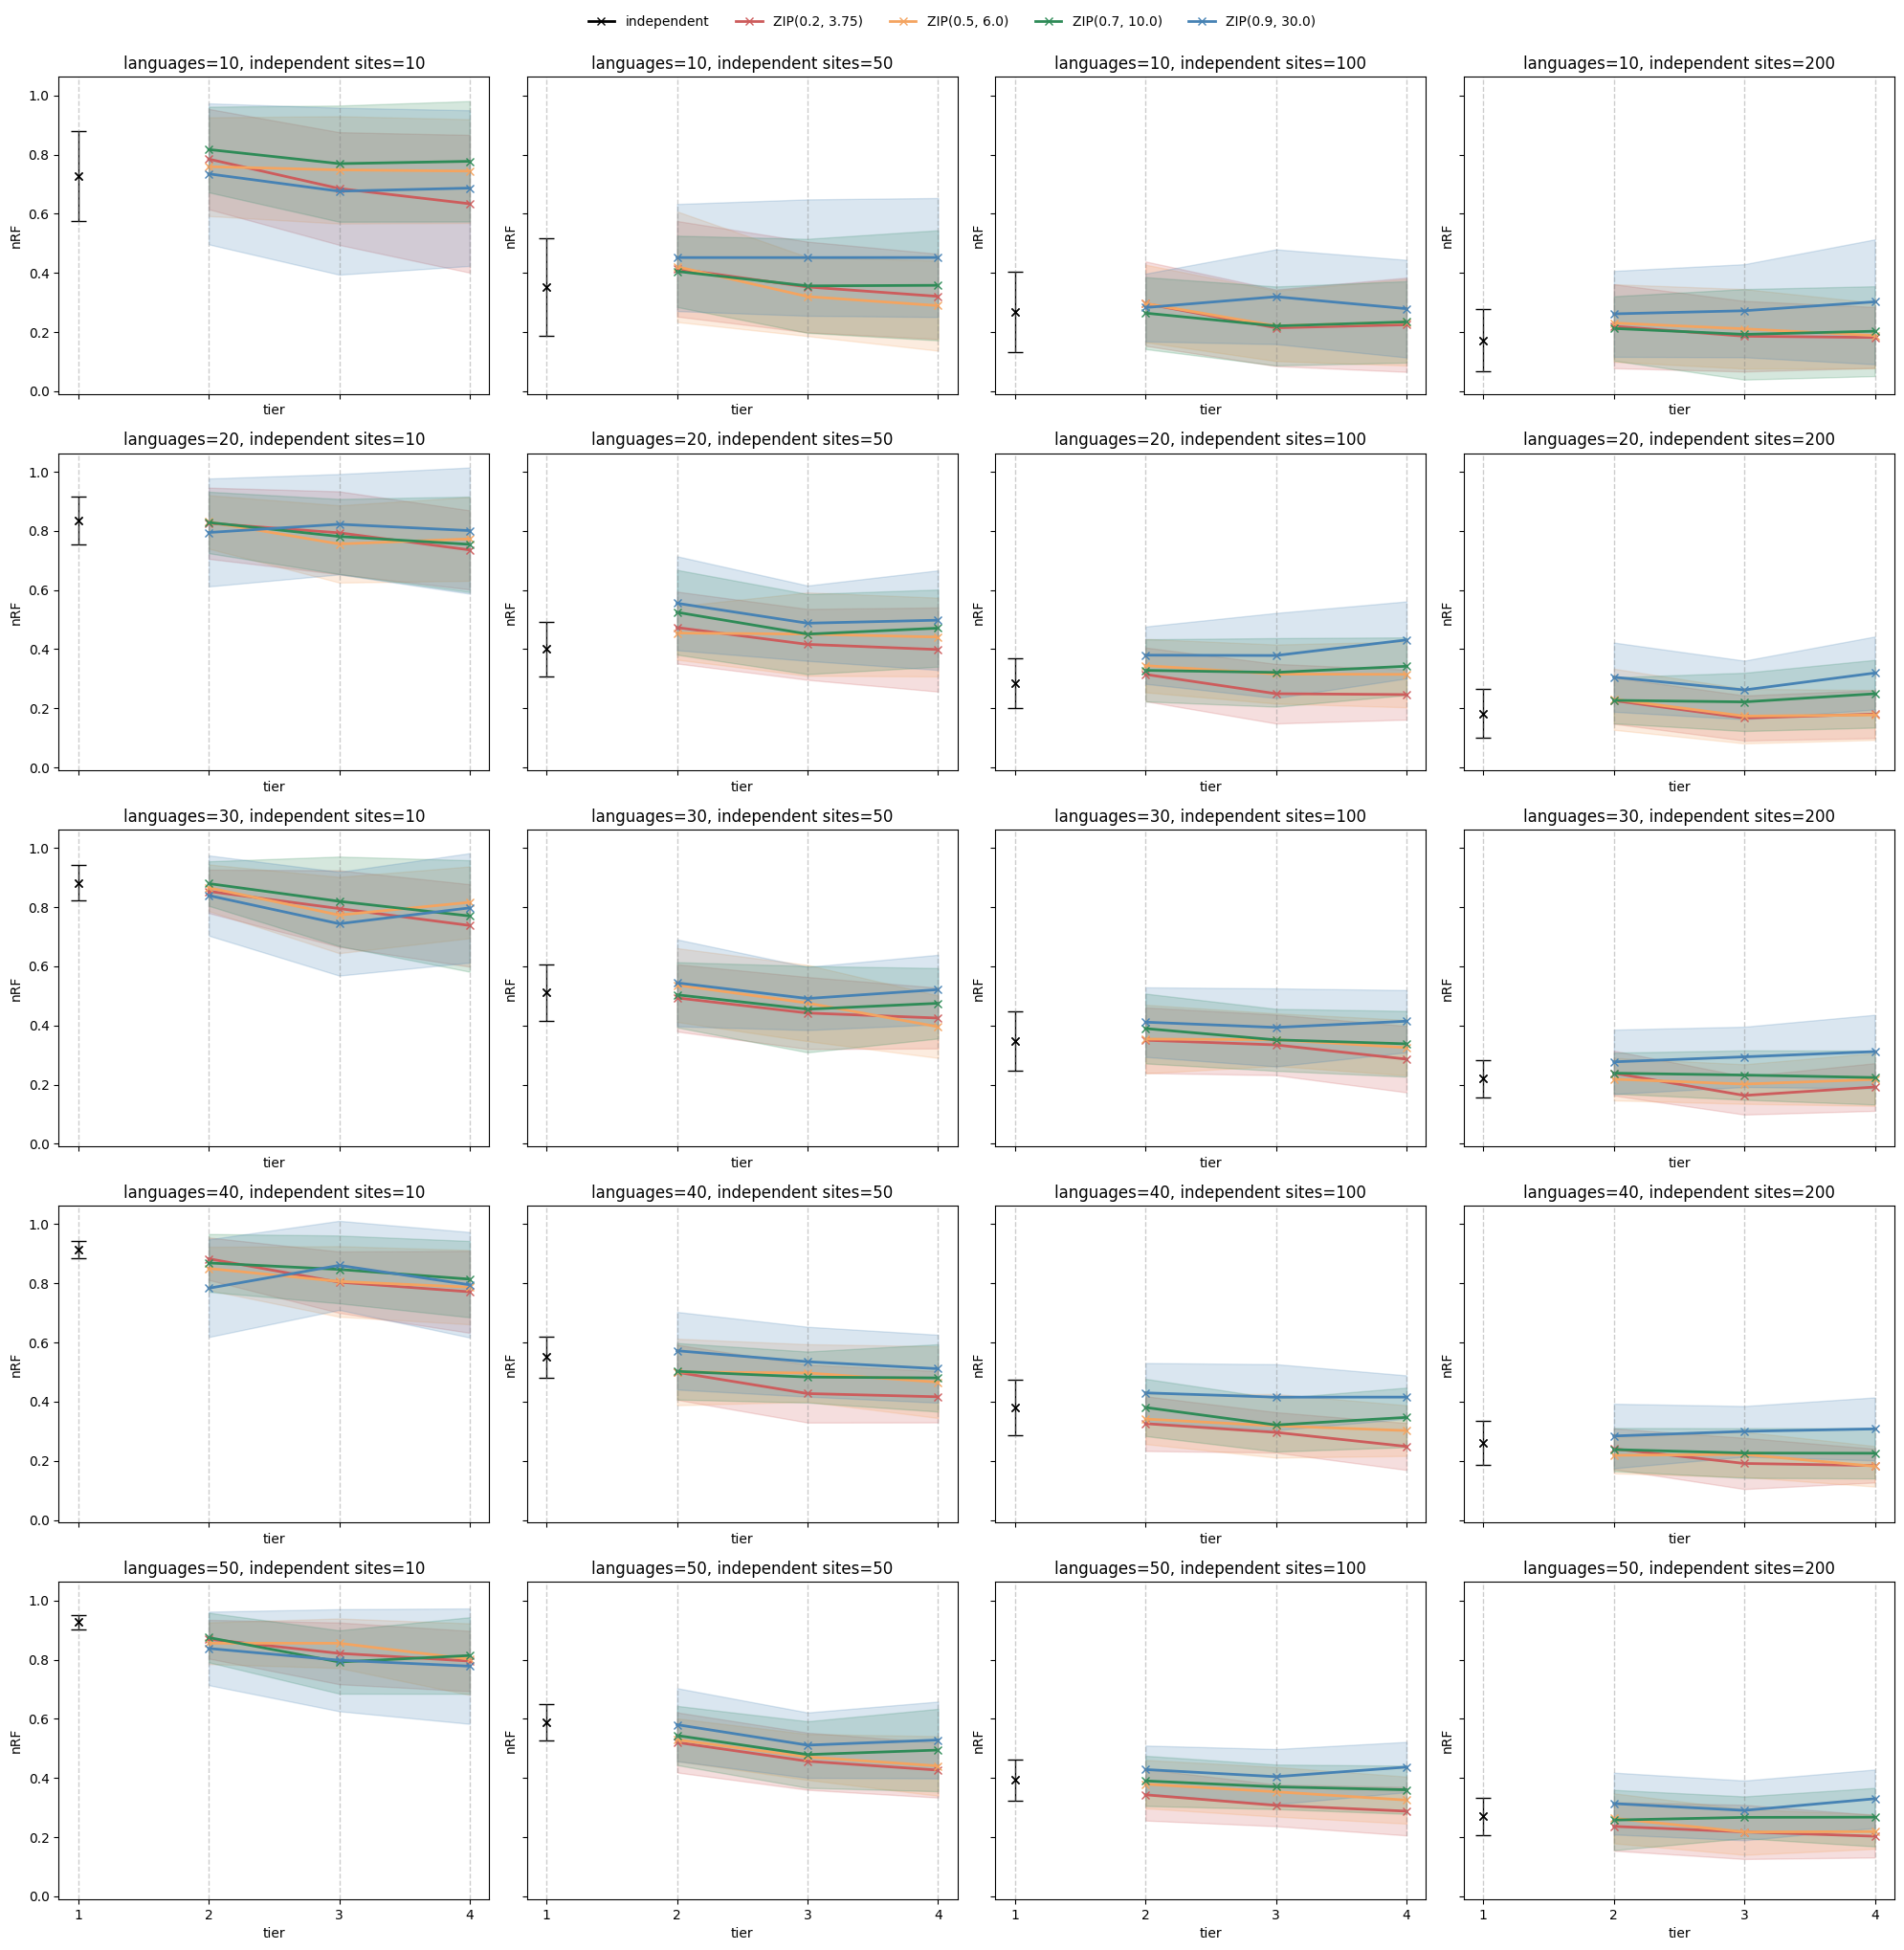

In [ ]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

colors = ["black", "indianred", "sandybrown", "seagreen", "steelblue"]
for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        if test:
            ax = axes
        else:
            ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["meanNRF"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("nRF")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
if test:
    handles, labels = axes.get_legend_handles_labels()
else:
    handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

- Clearly more independent data is better from the plot (compare blue dots from left to right)
- But with more independent data adding tiers to the data is less useful (marginal improvement decreases?)
- In most cases, having more dependent data improves the model recovery
- Interestingly, generation needs to be extremely selective or extremely widespread - having ZIP(0.5, 6) actually nullifies the effect of more dependent tiers


make uninteresting plots
- plot amount of data that was created for each step

# Clade Recovery against extra tiers

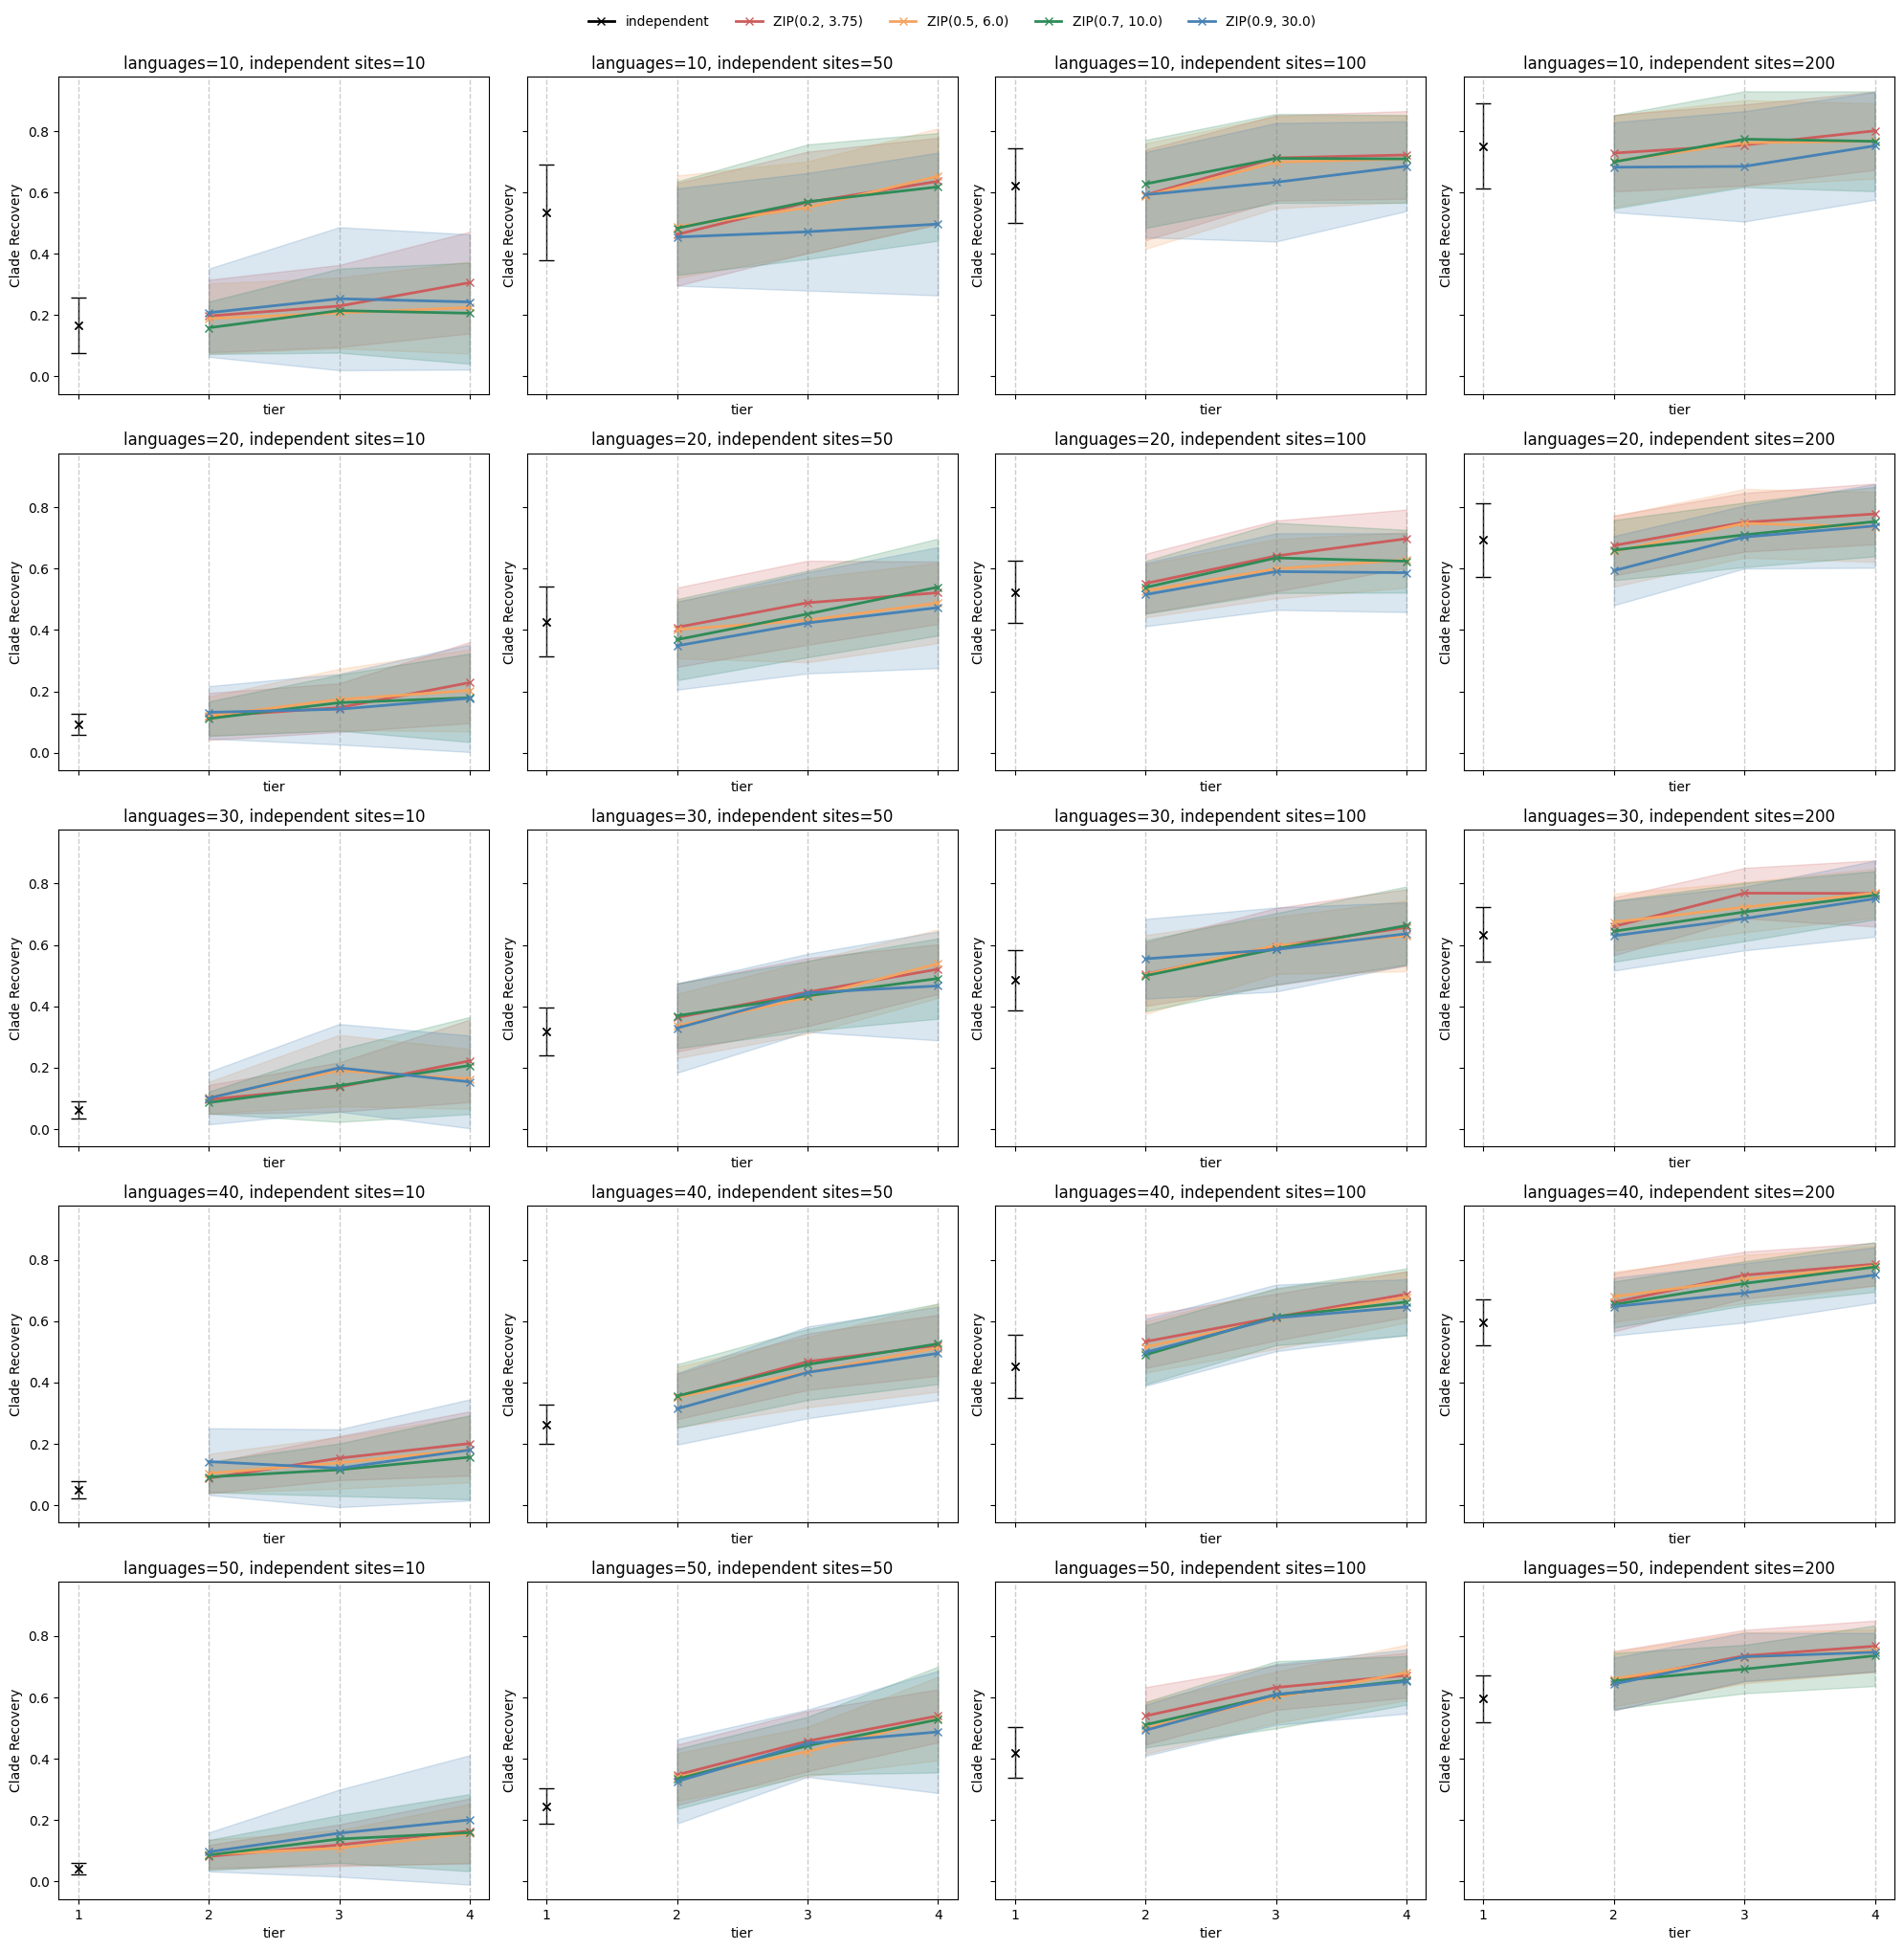

In [6]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

colors = ["black", "indianred", "sandybrown", "seagreen", "steelblue"]

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["HighSupportCladesProp"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("Clade Recovery")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

# nRF against Clade Recovery (correlation perhaps?)

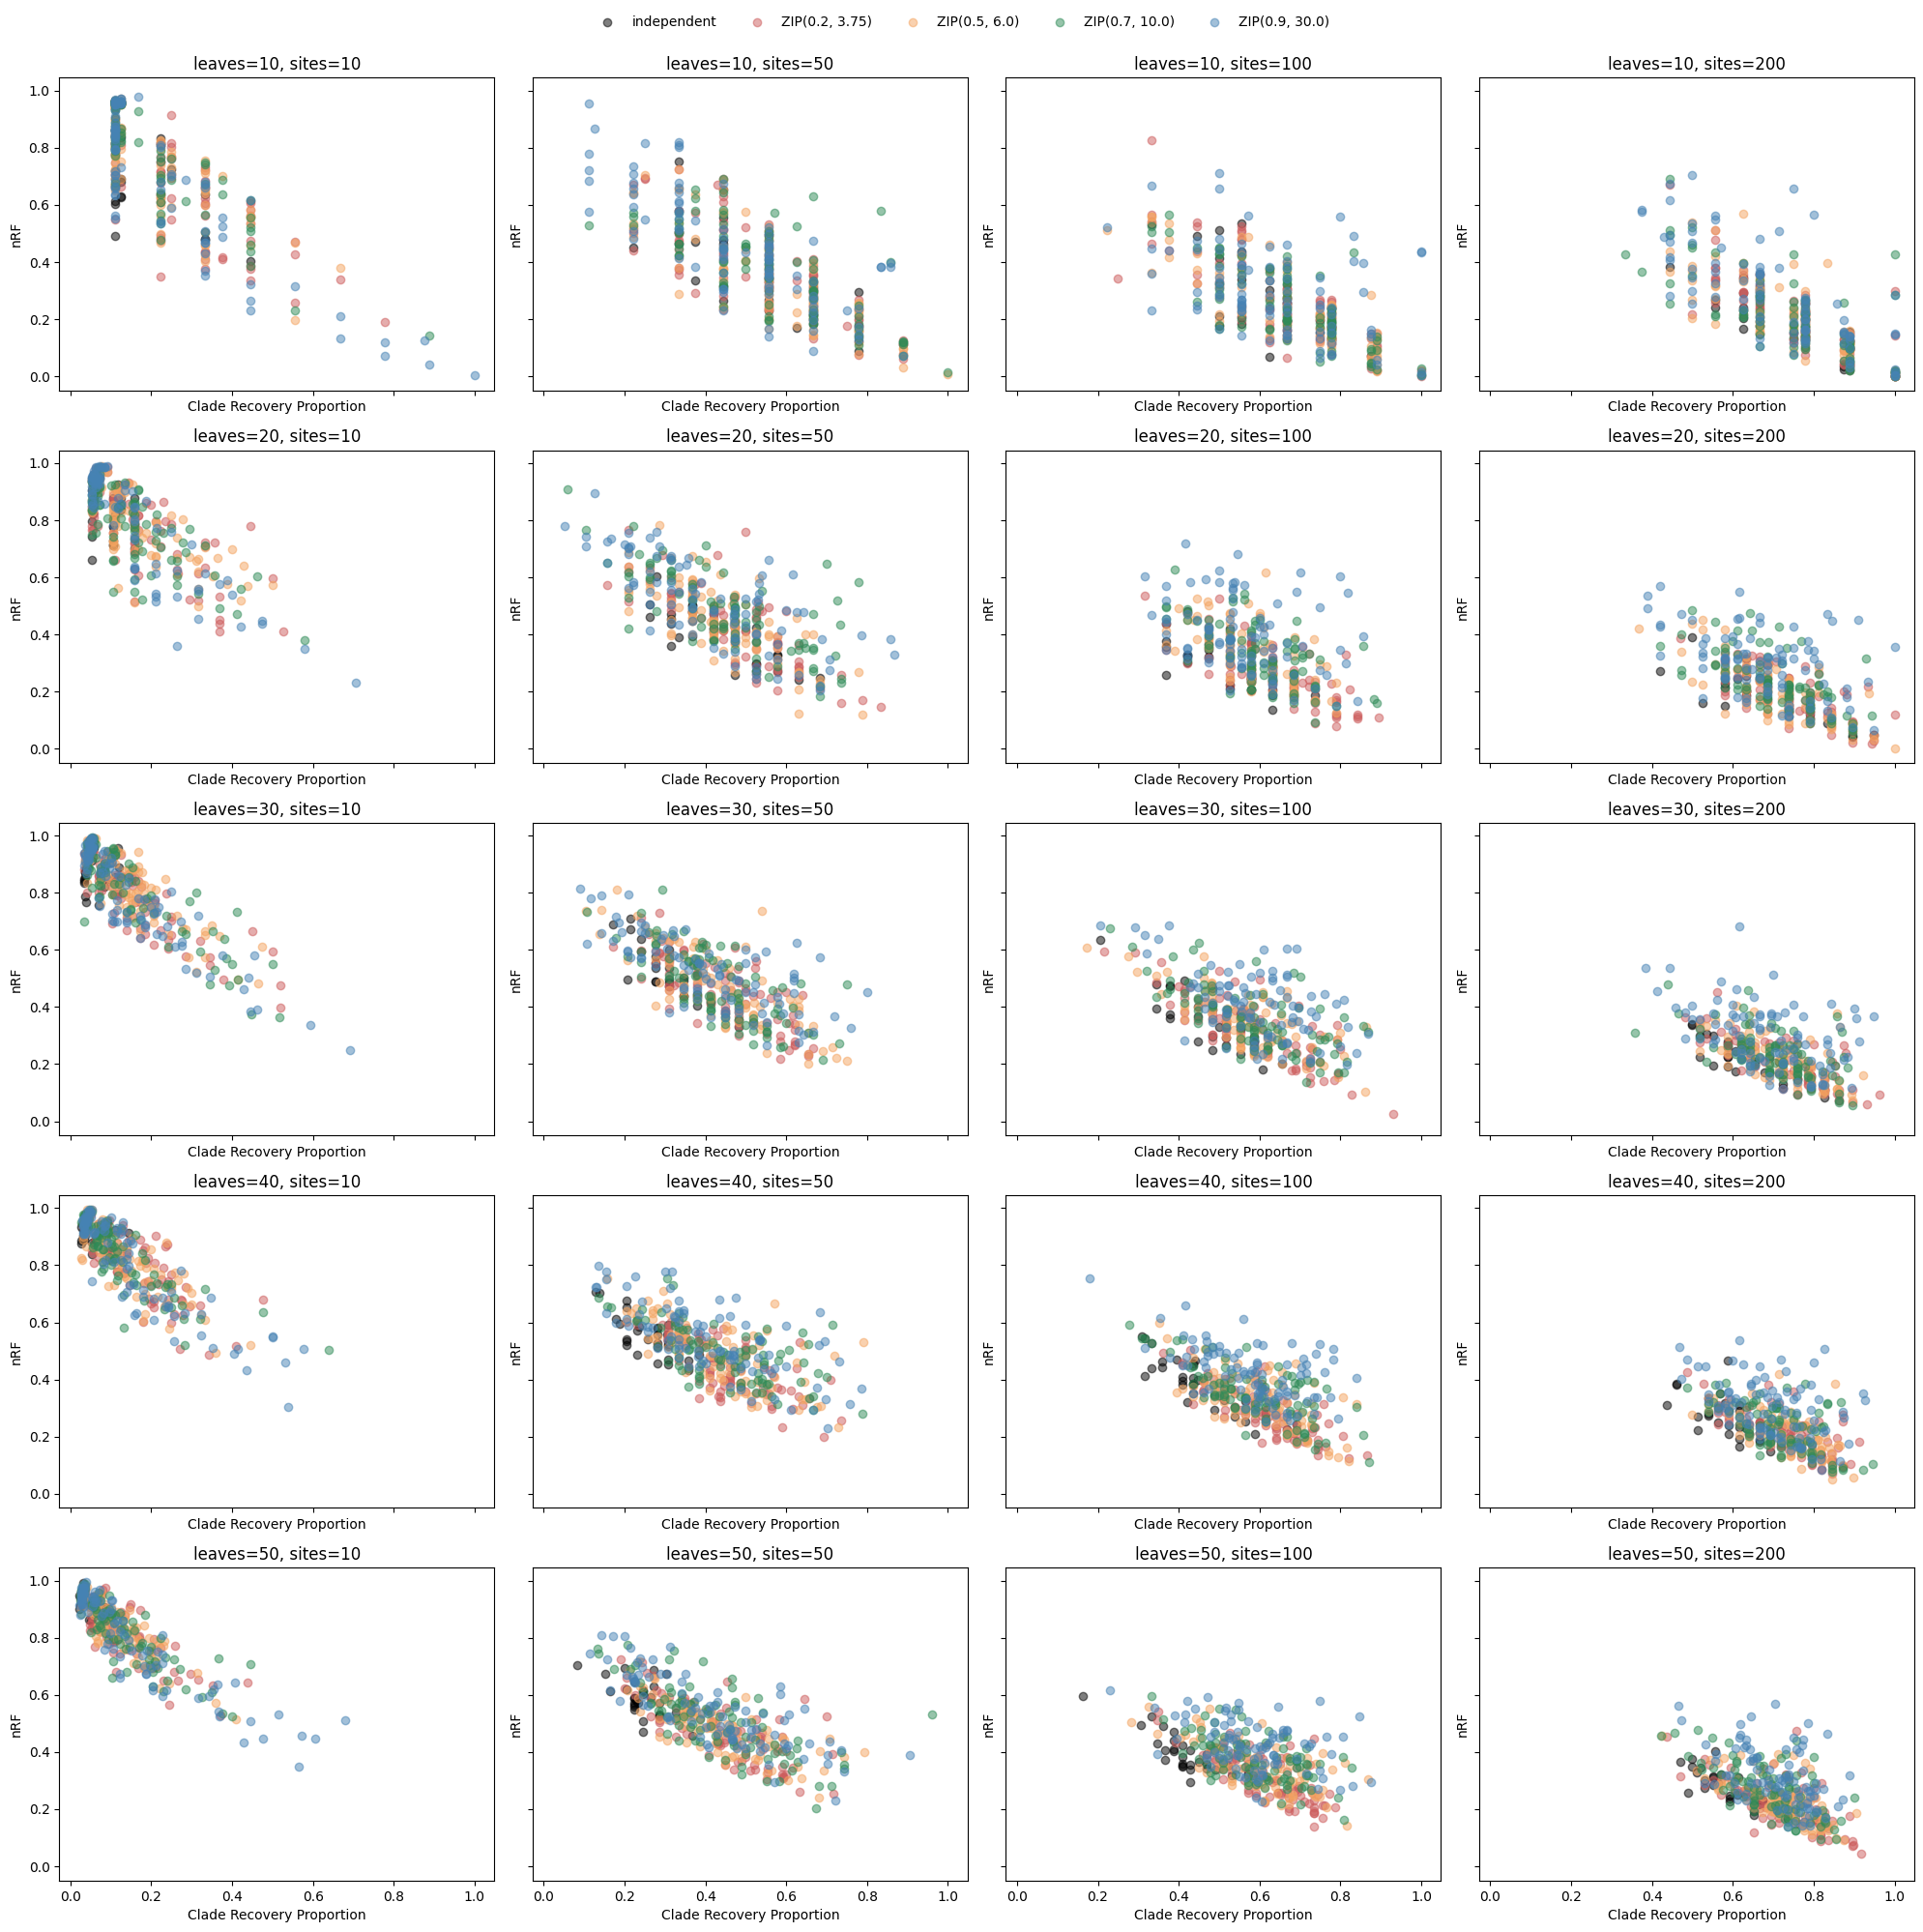

In [7]:
fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):

        ax = axes[i, j]

        d = df[
            (df["leaves"] == leaves_val) &
            (df["independent_sites"] == sites_val)
        ].copy()

        if d.empty:
            ax.set_visible(False)
            continue

        methods = d["ZIP"].unique()

        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]

            ax.scatter(
                dm["HighSupportCladesProp"],
                dm["meanNRF"],
                alpha=0.5,
                label=m,
                color=colors[k]
            )

        ax.set_title(f"leaves={leaves_val}, sites={sites_val}")
        ax.set_xlabel("Clade Recovery Proportion")
        ax.set_ylabel("nRF")


handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Tradeoff? not sure how to read this

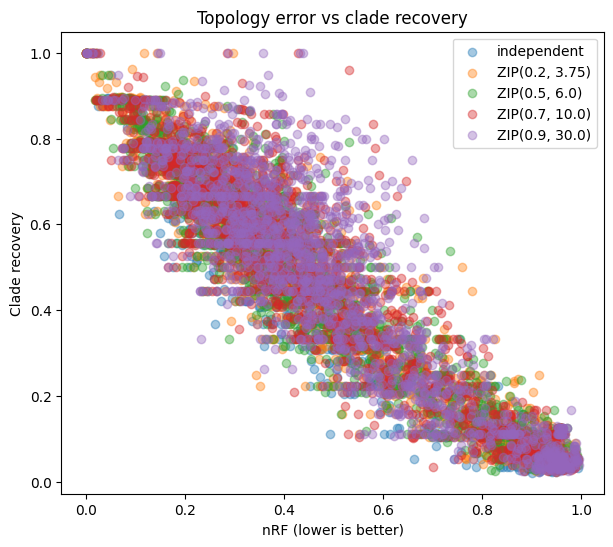

In [8]:
plt.figure(figsize=(7,6))

for m in df["ZIP"].unique():
    d = df[df["ZIP"] == m]

    plt.scatter(
        d["meanNRF"],
        d["HighSupportCladesProp"],
        alpha=0.4,
        label=m
    )

plt.xlabel("nRF (lower is better)")
plt.ylabel("Clade recovery")
plt.title("Topology error vs clade recovery")
plt.legend()
plt.show()

In [9]:
df.groupby(["leaves", "independent_sites", "tier"])[
    ["meanNRF", "HighSupportCladesProp"]
].corr()

meanNRF  \
leaves independent_sites tier                                   
10     10                1    meanNRF                1.000000   
                              HighSupportCladesProp -0.556012   
                         2    meanNRF                1.000000   
                              HighSupportCladesProp -0.795008   
                         3    meanNRF                1.000000   
...                                                       ...   
50     200               2    HighSupportCladesProp -0.688027   
                         3    meanNRF                1.000000   
                              HighSupportCladesProp -0.576789   
                         4    meanNRF                1.000000   
                              HighSupportCladesProp -0.598772   

                                                     HighSupportCladesProp  
leaves independent_sites tier                                               
10     10                1    meanNRF                            -0.556012  
                              HighSupportCladesProp               1.000000  
                         2    meanNRF                            -0.795008  
                              HighSupportCladesProp               1.000000  
                         3    meanNRF                            -0.865963  
...                                                                    ...  
50     200               2    HighSupportCladesProp               1.000000  
                         3    meanNRF                            -0.576789  
                              HighSupportCladesProp               1.000000  
                         4    meanNRF                            -0.598772  
                              HighSupportCladesProp               1.000000  

[160 rows x 2 columns]

In [10]:
df

,meanRF,varRF,meanNRF,varNRF,HighSupportCladesProp,likelihoodESS,priorESS,jointESS,tier,ZIP,leaves,independent_sites
0,12.038218,1.936317,0.859873,0.009879,0.111111,7779.927900,7130.301395,6624.764767,1,independent,10,10
1,13.310521,1.498344,0.950752,0.007645,0.111111,8538.757505,6272.019059,6462.087486,2,"ZIP(0.2, 3.75)",10,10
2,13.150983,1.925757,0.939356,0.009825,0.111111,5744.611782,1191.699894,1204.859985,3,"ZIP(0.2, 3.75)",10,10
3,7.895345,3.665046,0.563953,0.018699,0.333333,6871.699926,8359.110064,8496.169601,4,"ZIP(0.2, 3.75)",10,10
4,11.927786,1.926785,0.851985,0.009831,0.111111,6830.391321,4533.235870,4811.090260,2,"ZIP(0.5, 6.0)",10,10
...,...,...,...,...,...,...,...,...,...,...,...,...
7795,22.948561,11.814354,0.244134,0.001337,0.652174,4600.607700,1975.516628,3538.510517,3,"ZIP(0.7, 10.0)",50,200
7796,30.073770,6.178557,0.319934,0.000699,0.681818,5430.216627,2142.153351,4738.737828,4,"ZIP(0.7, 10.0)",50,200
7797,31.914898,8.242979,0.339520,0.000933,0.690476,5795.712032,2203.900349,4428.615057,2,"ZIP(0.9, 30.0)",50,200
7798,27.505833,21.190438,0.292615,0.002398,0.644444,2.359258,3.995255,2.267960,3,"ZIP(0.9, 30.0)",50,200


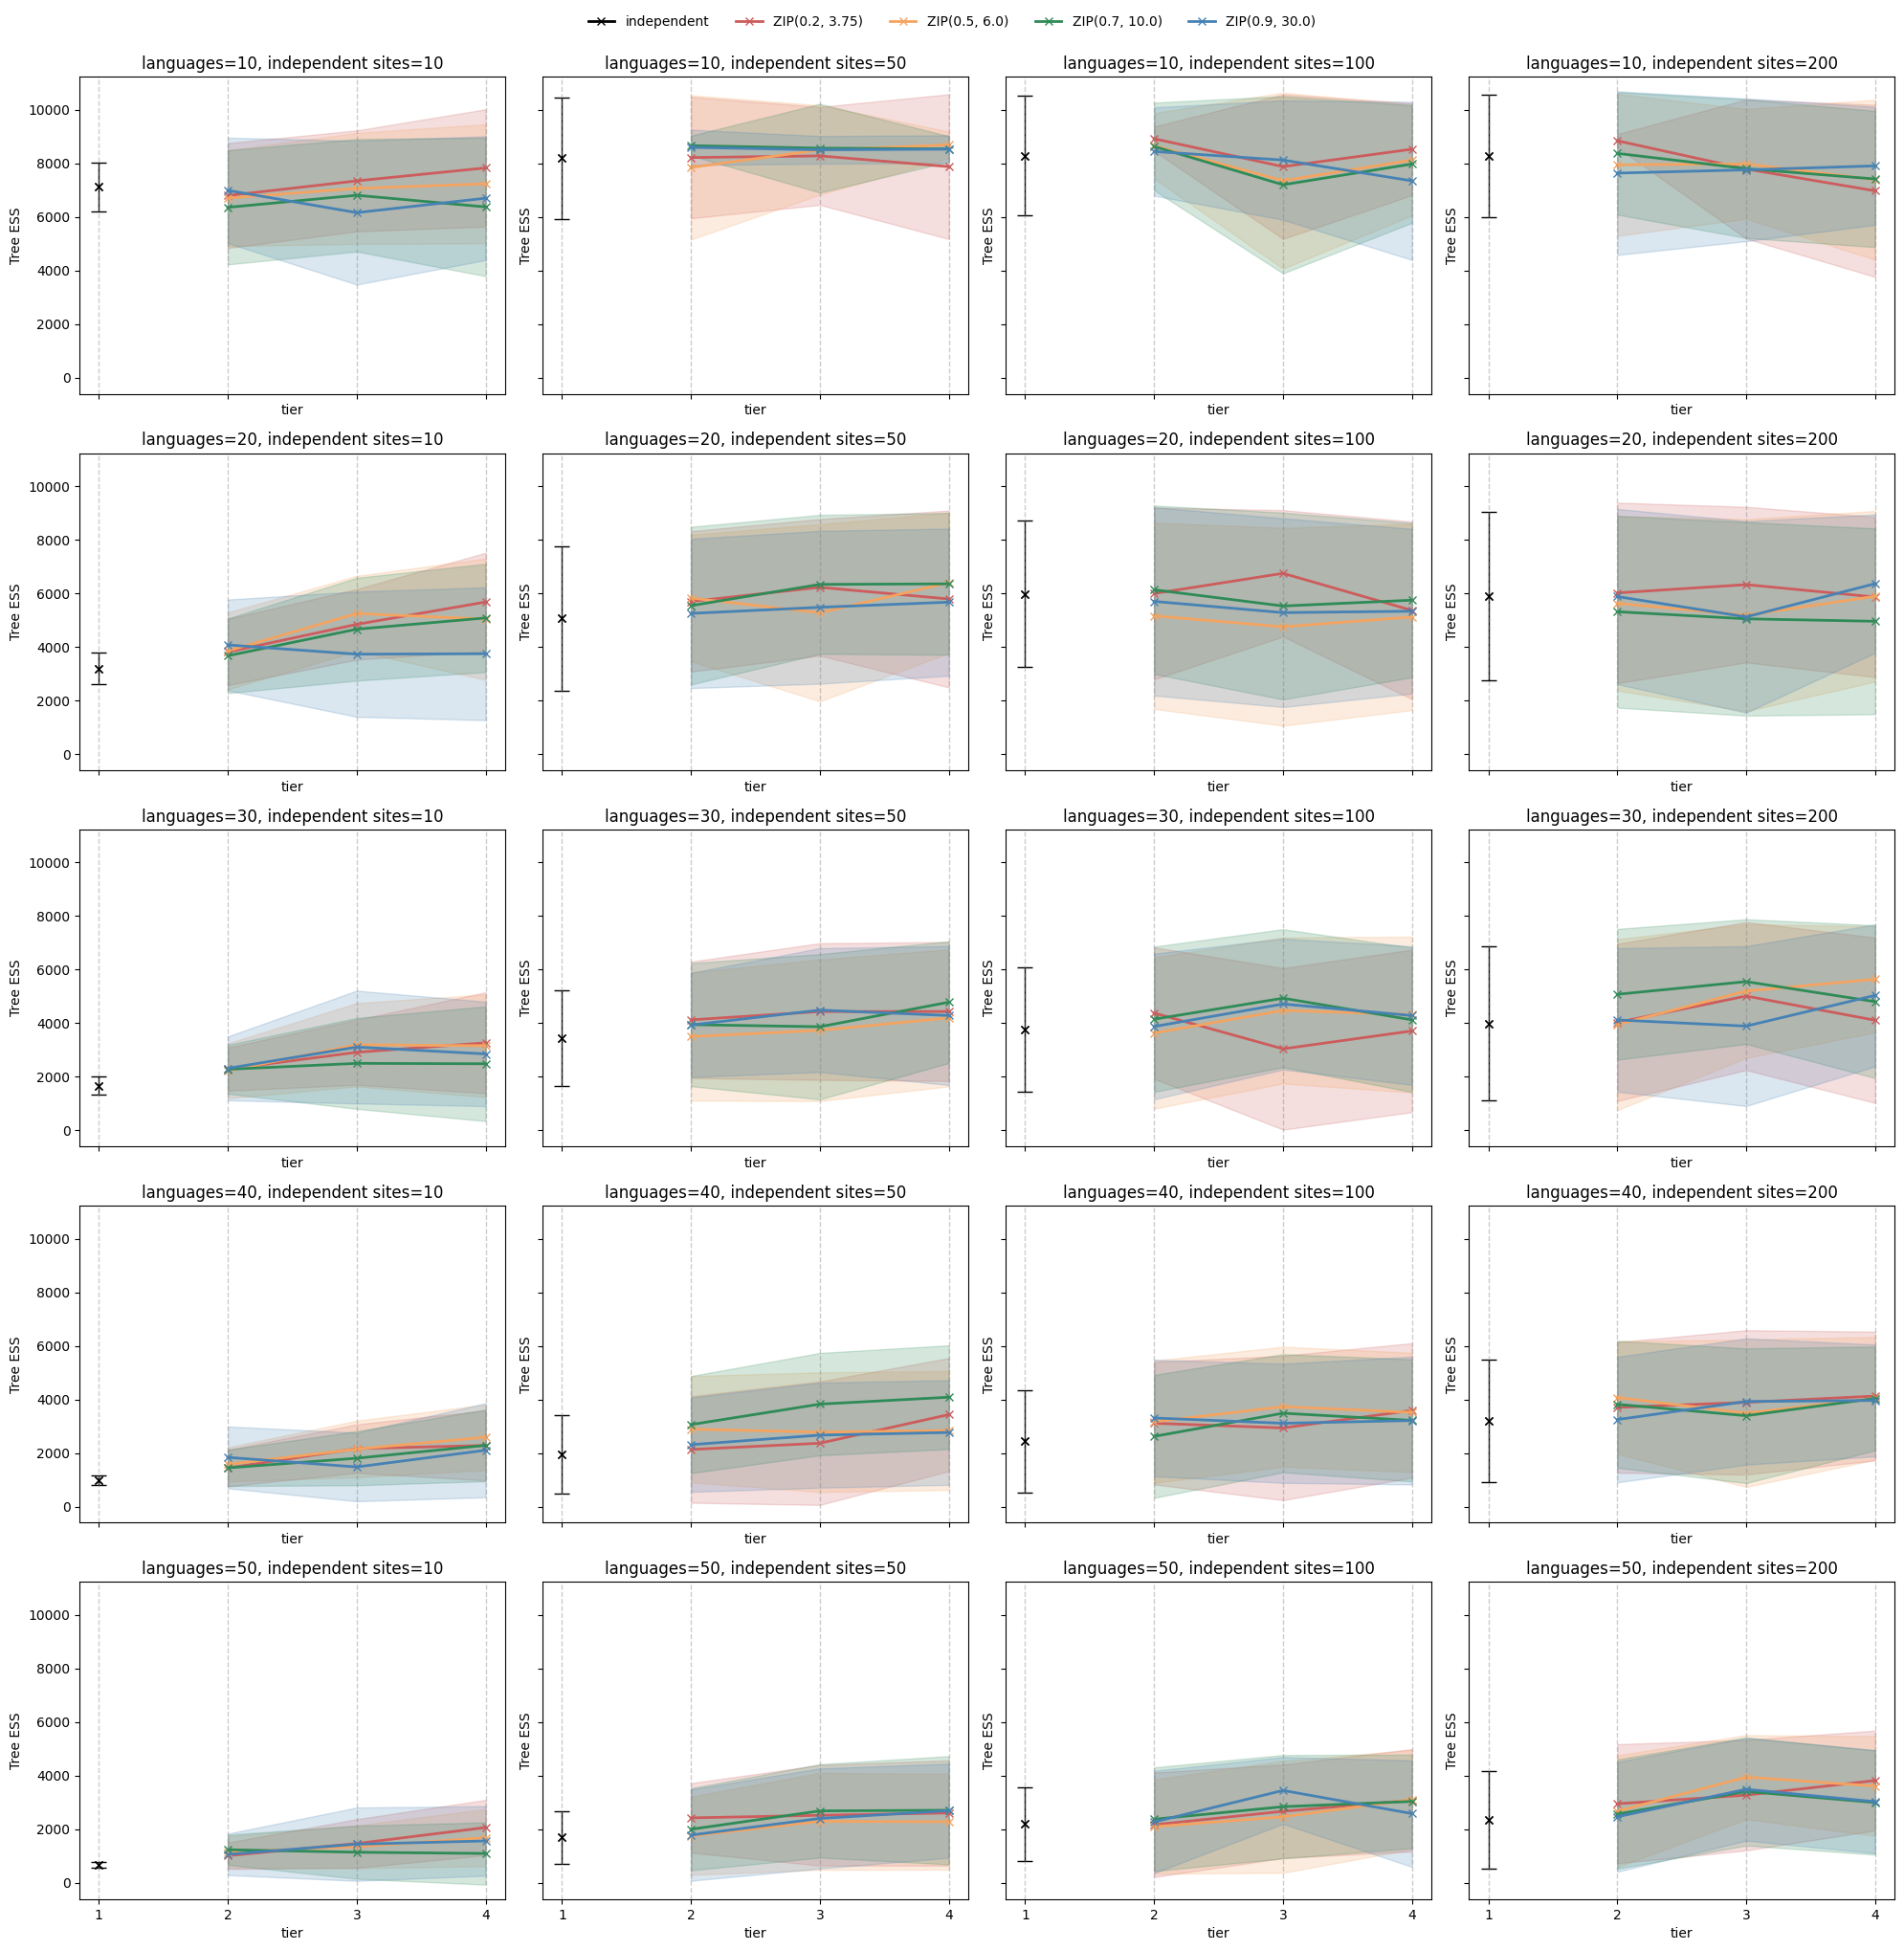

In [11]:
df["tier"] = pd.to_numeric(df["tier"])
df["meanNRF"] = pd.to_numeric(df["meanNRF"])
df["leaves"] = pd.to_numeric(df["leaves"])
df["independent_sites"] = pd.to_numeric(df["independent_sites"])

leaves_vals = sorted(df["leaves"].unique())
sites_vals = sorted(df["independent_sites"].unique())

fig, axes = plt.subplots(
    len(leaves_vals),
    len(sites_vals),
    figsize=(5 * len(sites_vals), 4 * len(leaves_vals)),
    sharex=True,
    sharey=True
)

colors = ["black", "indianred", "sandybrown", "seagreen", "steelblue"]

for i, leaves_val in enumerate(leaves_vals):
    for j, sites_val in enumerate(sites_vals):
        ax = axes[i, j]
        d = df[(df["leaves"] == leaves_val) & (df["independent_sites"] == sites_val)].copy()
        if d.empty:
            ax.set_visible(False)
            continue
        methods = d["ZIP"].unique()
        for k, m in enumerate(methods):
            dm = d[d["ZIP"] == m]
            grouped = dm.groupby("tier")["jointESS"]
            mean = grouped.mean()
            std = grouped.std()
            x = mean.index.values
            color = colors[k]
            ax.plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
            if m == "independent":
                ax.errorbar(
                    x,
                    mean.values,
                    yerr=std.values,
                    fmt='x',
                    color=color,
                    linewidth=1,
                    capsize=6,
                    capthick=1,
                    label=m
                )
            else:
                ax.fill_between(
                    x,
                    mean - std,
                    mean + std,
                    color=color,
                    alpha=0.2
                )
        ax.set_title(f"languages={leaves_val}, independent sites={sites_val}")
        ax.set_xlabel("tier")
        ax.set_ylabel("Tree ESS")
        ax.set_xticks([1, 2, 3, 4])
        for x in [1, 2, 3, 4]:
            ax.axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles[:-1],
    labels[:-1],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.tight_layout()
plt.show()

## Validation

### Validation 1: Model fits independent data well

In [19]:
val1_data = pd.read_csv("validation1/postprocessing/val1_combined_data.csv")

In [20]:
val1_data

,meanRF,varRF,meanNRF,varNRF,HighSupportCladesProp,likelihoodESS,priorESS,jointESS,tier,ZIP,leaves,independent_sites
0,9.245417,5.946097,0.660387,0.030337,0.111111,8496.533316,7104.894784,7355.453530,1,"ZIP(0, 0)",10,10
1,9.631596,4.167375,0.687971,0.021262,0.125000,8629.131270,8212.392973,8209.409257,1,"ZIP(0, 0)",10,50
2,1.706477,1.512501,0.121891,0.007717,0.777778,9001.000000,9001.000000,9001.000000,1,"ZIP(0, 0)",10,100
3,3.710699,1.366073,0.265050,0.006970,0.666667,9001.000000,8407.742012,9001.000000,1,"ZIP(0, 0)",10,500
4,2.258194,1.722662,0.161300,0.008789,0.750000,8569.386866,9001.000000,8621.383132,1,"ZIP(0, 0)",10,1000
...,...,...,...,...,...,...,...,...,...,...,...,...
795,11.931341,9.130841,0.126929,0.001033,0.795918,6439.046309,2513.949810,5119.533372,1,"ZIP(0, 0)",50,500
796,15.338296,3.719432,0.163173,0.000421,0.909091,4905.239226,21.526912,4661.413173,1,"ZIP(0, 0)",50,1000
797,1.219198,0.959169,0.012970,0.000109,0.979592,5076.533354,4561.620871,5137.687154,1,"ZIP(0, 0)",50,5000
798,10.491501,3.916622,0.111612,0.000443,0.891304,4895.511078,1890.318492,5000.993259,1,"ZIP(0, 0)",50,10000


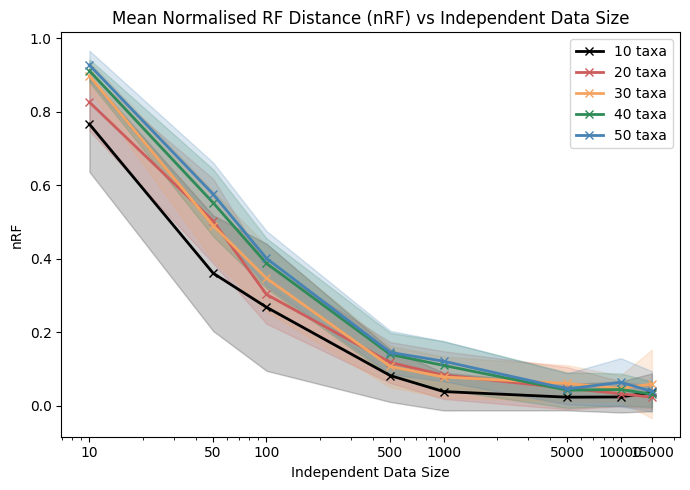

In [39]:
val1_data["tier"] = pd.to_numeric(val1_data["tier"])
val1_data["meanNRF"] = pd.to_numeric(val1_data["meanNRF"])
val1_data["leaves"] = pd.to_numeric(val1_data["leaves"])
val1_data["independent_sites"] = pd.to_numeric(val1_data["independent_sites"])
leaves_vals = sorted(val1_data["leaves"].unique())

fig, axes = plt.subplots(1, 1,
    figsize=(7, 5),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):        
    d = val1_data[(val1_data["leaves"] == leaves_val)].copy()
    if d.empty:
        axes.set_visible(False)
        continue
    grouped = d.groupby("independent_sites")["meanNRF"]
    mean = grouped.mean()
    std = grouped.std()
    x = mean.index.values
    color = colors[i]
    axes.plot(x, mean.values, marker="x", color=color, linewidth=2, label=f"{leaves_val} taxa")
    axes.fill_between(
        x,
        mean - std,
        mean + std,
        color=color,
        alpha=0.2
    )
axes.set_xscale("log")
axes.set_title(f"Mean Normalised RF Distance (nRF) vs Independent Data Size")
axes.set_xlabel("Independent Data Size")
axes.set_ylabel("nRF")
axes.set_xticks(x)
axes.set_xticklabels(x)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.tight_layout()
plt.legend()
plt.show()

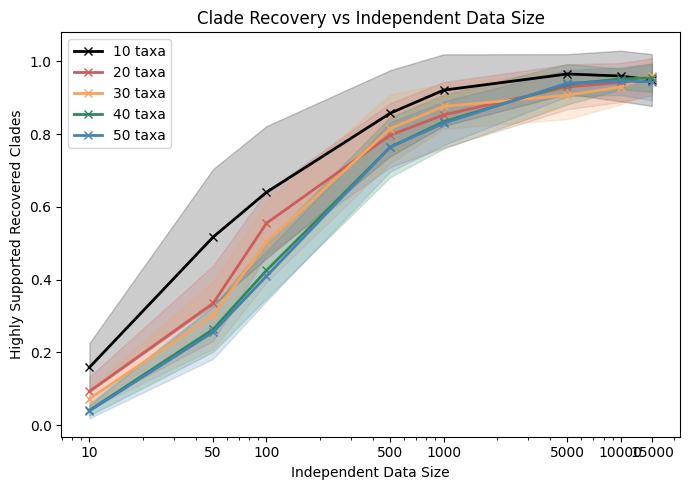

In [38]:
fig, axes = plt.subplots(1, 1,
    figsize=(7, 5),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):        
    d = val1_data[(val1_data["leaves"] == leaves_val)].copy()
    if d.empty:
        axes.set_visible(False)
        continue
    grouped = d.groupby("independent_sites")["HighSupportCladesProp"]
    mean = grouped.mean()
    std = grouped.std()
    x = mean.index.values
    color = colors[i]
    axes.plot(x, mean.values, marker="x", color=color, linewidth=2, label=f"{leaves_val} taxa")
    axes.fill_between(
        x,
        mean - std,
        mean + std,
        color=color,
        alpha=0.2
    )
axes.set_xscale("log")
axes.set_title(f"Clade Recovery vs Independent Data Size")
axes.set_xlabel("Independent Data Size")
axes.set_ylabel("Highly Supported Recovered Clades")
axes.set_xticks(x)
axes.set_xticklabels(x)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.tight_layout()
plt.legend()
plt.show()

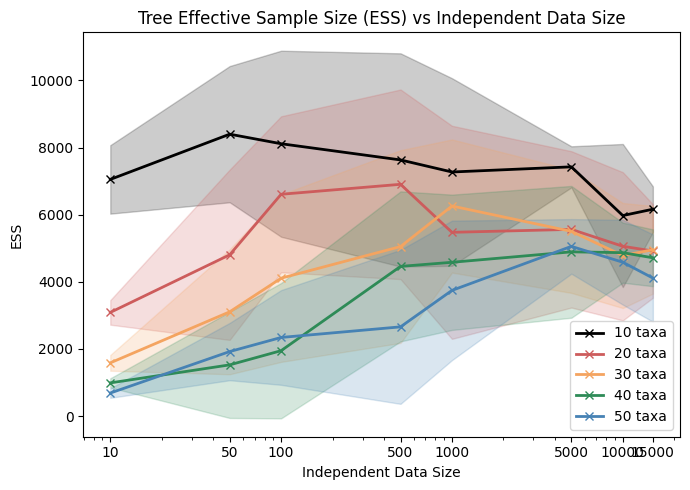

In [41]:
fig, axes = plt.subplots(1, 1,
    figsize=(7, 5),
    sharex=True,
    sharey=True
)

for i, leaves_val in enumerate(leaves_vals):        
    d = val1_data[(val1_data["leaves"] == leaves_val)].copy()
    if d.empty:
        axes.set_visible(False)
        continue
    grouped = d.groupby("independent_sites")["jointESS"]
    mean = grouped.mean()
    std = grouped.std()
    x = mean.index.values
    color = colors[i]
    axes.plot(x, mean.values, marker="x", color=color, linewidth=2, label=f"{leaves_val} taxa")
    axes.fill_between(
        x,
        mean - std,
        mean + std,
        color=color,
        alpha=0.2
    )
axes.set_xscale("log")
axes.set_title(f"Tree Effective Sample Size (ESS) vs Independent Data Size")
axes.set_xlabel("Independent Data Size")
axes.set_ylabel("ESS")
axes.set_xticks(x)
axes.set_xticklabels(x)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.tight_layout()
plt.legend()
plt.show()

### Validation 2: Dependent Data generates as expected

/rds/general/user/jst21/home/m4r/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/rds/general/user/jst21/home/m4r/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/rds/general/user/jst21/home/m4r/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/rds/general/user/jst21/home/m4r/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/rds/general/user/jst21/home/m4r/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwa

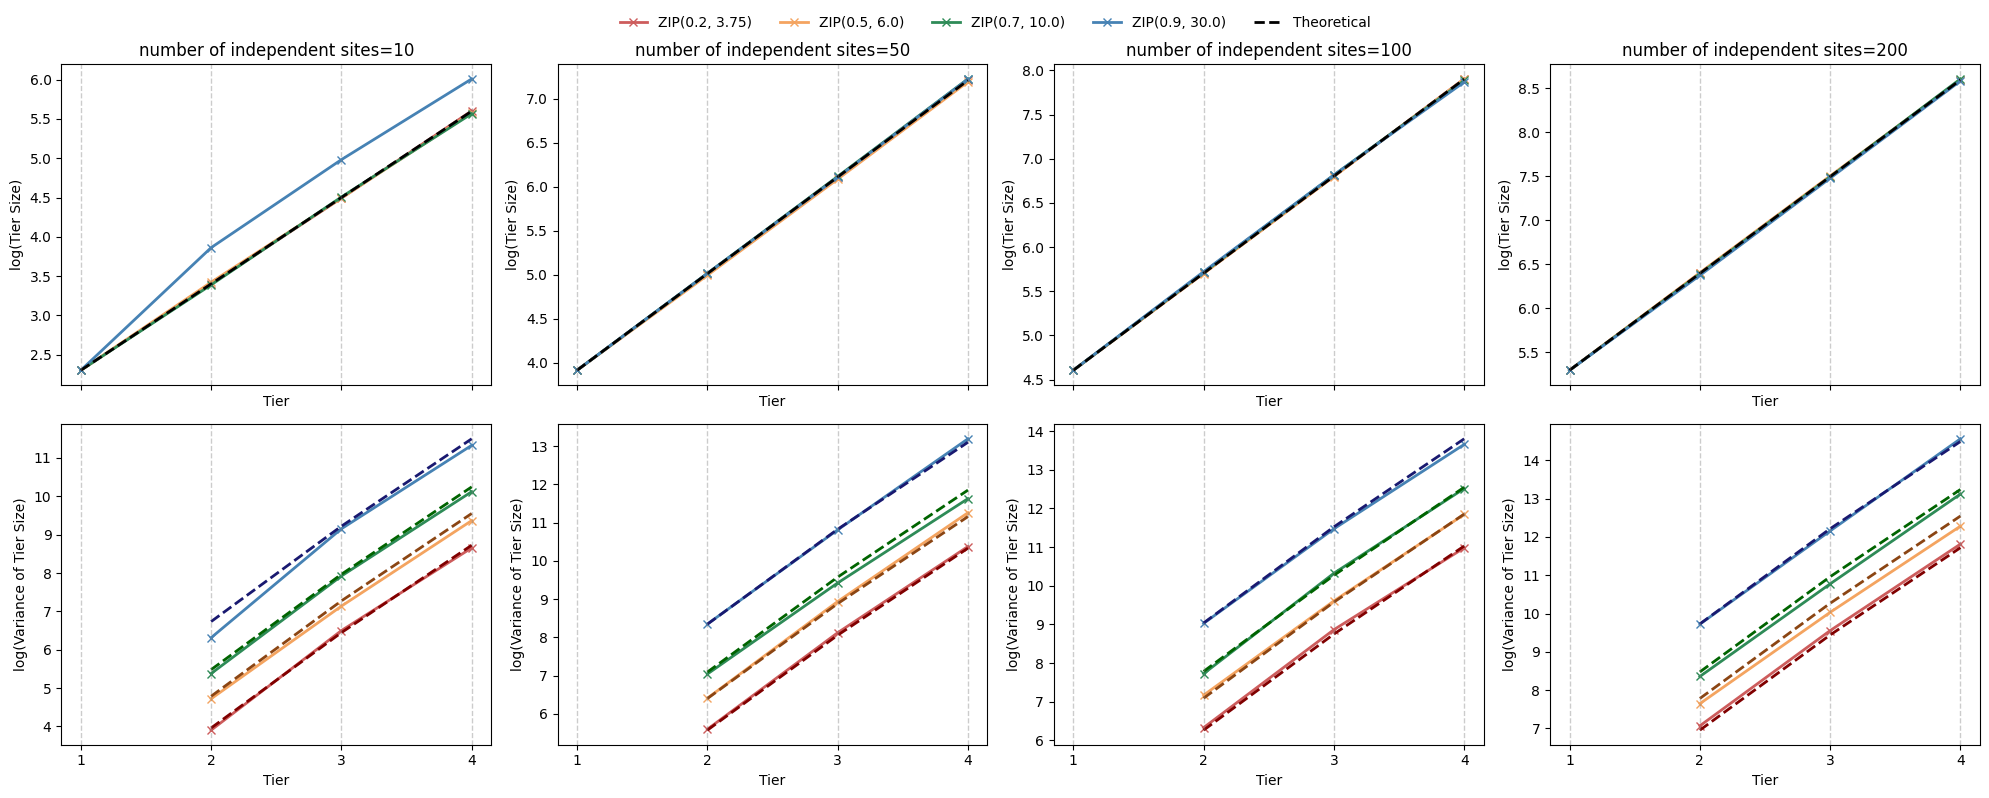

In [16]:
sizes = pd.read_csv("../figures/exp2/exp2_combined_sizes.csv")

fig, axes = plt.subplots(
    2,
    len(sites_vals),
    figsize=(5 * len(sites_vals), 8),
    sharex=True
)

theoretical_colors = ["black", "maroon", "saddlebrown", "darkgreen", "midnightblue"]

for j, sites_val in enumerate(sites_vals):
    d = sizes[
        (sizes["independent_sites"] == sites_val)
    ].copy()

    if d.empty:
        axes[0, j].set_visible(False)
        continue

    methods = d["site_dep_param"].unique()
    for k, m in enumerate(methods):
        p, lam = list(float(x) for x in m[4:-1].split(', '))
        dm = d[d["site_dep_param"] == m]
        grouped = dm.groupby("current tier")["size"]
        mean = np.log(grouped.mean())
        var = np.log(grouped.var())
        x = mean.index.values
        color = colors[k+1]
        axes[0, j].plot(x, mean.values, marker="x", color=color, linewidth=2, label=m)
        axes[1, j].plot(x, var.values, marker='x', color=color, linewidth=2, label=m)

        # Theoretical Values
        x = np.array([1, 2, 3, 4])
        ### If lambda(1-p) = mu, mu = 3 != 1
        mean = np.log((1-p)*lam)
        var = np.log((1-p)*lam + p*(1-p)*lam**2)
        variances = np.log(sites_val) + var + (x[1:]-2)*mean + np.log(np.exp(mean)**(x[1:]-1) - 1) - np.log(np.exp(mean)- 1)
        axes[1, j].plot(x[1:], variances, color=theoretical_colors[k+1], linestyle="--", linewidth=2)
    axes[0, j].plot(x, np.log(sites_val) + (x-1)*mean, color=theoretical_colors[0], linestyle="--", linewidth=2, label='Theoretical')
    axes[0, j].set_title(f"number of independent sites={sites_val}")
    axes[0, j].set_xlabel("Tier")
    axes[0, j].set_ylabel("log(Tier Size)")
    axes[1, j].set_xlabel("Tier")
    axes[1, j].set_ylabel("log(Variance of Tier Size)")
    axes[1, j].set_xticks([1, 2, 3, 4])
    for x in [1, 2, 3, 4]:
        axes[0, j].axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")
        axes[1, j].axvline(x, linestyle="--", linewidth=1, alpha=0.4, color="grey")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    ncol=5,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [17]:
sum(sizes.groupby("current tier")["size"].max())

15203